In [1]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np
import sqlite3
import warnings
warnings.filterwarnings("ignore")

In [2]:
#1. import database/data

In [3]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
      SELECT name
      FROM sqlite_master
      WHERE type='table'

"""

tables = pd.read_sql(sql_query, conn)


for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [4]:
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")

    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [5]:
# 2. data cleaning

In [6]:
#df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [7]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [8]:
# a.rename col name
# b.drop column - interest and pincode
# c.change data type - dob
# d. data standardization - gender
# e. fix missing values - country

In [9]:
# a.rename col -  name

df_db_customer.rename(columns = {'name' : 'cutomer_name'}, inplace= True)
df_db_customer


,customerid,cutomer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [10]:
# b. drop column - interest and pincode

#df_db_customer.drop(df_db_customer.columns[-2:], axis=1)

df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)

In [11]:
# c.change data type - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [12]:
# d. data standardization - gender

#df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})

In [13]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [14]:
# e. fix missing values - country

df_db_customer[df_db_customer['country'].isna()]

,customerid,cutomer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [15]:
# country and state unique value pair

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [16]:
df_db_customer[df_db_customer['country'].isna()]


,customerid,cutomer_name,country,state,gender,dob


In [17]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [18]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [19]:
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info

<bound method DataFrame.info of     customerid subscription_start_date subscription_type renewal_date  \
0   0002-ORFBO              2021-03-15          Refferal   2025-03-15   
1   0003-MKNFE              2020-08-01              Paid   2024-08-01   
2   0004-TLHLJ              2022-11-20           Organic   2025-11-20   
3   0011-IGKFF              2019-05-10              Paid   2025-05-10   
4   0013-EXCHZ              2023-01-05          Refferal   2024-01-05   
5   0013-MHZWF              2022-06-18              Paid   2025-06-18   
6   0013-SMEOE              2021-09-30          Refferal   2024-09-30   
7   0014-BMAQU              2020-02-14           Organic   2025-02-14   
8   0015-UOCOJ              2023-07-22           Organic   2024-07-22   
9   0016-QLJIS              2022-04-03           Organic   2025-04-03   
10  0017-DINOC              2021-12-01           Organic   2025-12-01   
11  0017-IUDMW              2023-03-17          Refferal   2024-03-17   
12  0018-NYROU     

In [20]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [21]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [22]:
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [23]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [24]:
# 3. Feature Engineering and Data Analysis

In [25]:
# create a new column using existing col - churn flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [26]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [27]:
# first fix support table duplicates then merge
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how= 'left' )
    .merge(df_db_support, on = 'customerid', how= 'left' ))


In [28]:
df.shape

(23, 20)

In [29]:
df_db_subscription.shape

(21, 12)

In [30]:
df_db_customer['customerid'].nunique()

21

In [31]:
df_db_subscription['customerid'].nunique()

21

In [32]:
df_db_support['customerid'].nunique()

7

In [33]:
df_db_support['customerid'].size

9

In [34]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [35]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [36]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep='last')

In [37]:
df_db_support['customerid'].size

7

In [38]:
# merge df
df = (df_db_subscription
    .merge(df_db_customer, on = 'customerid', how= 'left' )
    .merge(df_db_support, on = 'customerid', how= 'left' ))

In [39]:
df.shape

(21, 21)

In [40]:
df.to_csv('exported_churn_data.csv', index= False)

In [41]:
# Data Analysis

In [42]:
# 1. Churn Rate

In [43]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'cutomer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [44]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2), "%")

Churn Rate =  28.57 %


In [45]:
# 2. Retention Rate
retention_rate = 100- churn_rate
print("Retention Rate = ", round(retention_rate,2), "%")

Retention Rate =  71.43 %


In [46]:
df.head(2)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,cutomer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0


In [47]:
# 3. Churn by Plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))

print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [48]:
# 4 a. Churn by state  + sum (revenue) & count of users 
# 4 b. Churn by subscription type + sum (revenue) & count of users 

In [49]:
# 5. ARPU - Average Revenue Per User
arpu = df['monthly_charges'].mean()
print('ARPU=', round(arpu,2))

ARPU= 18.85


In [50]:
# 6. Average customer tenure
# count of days usres has used our service : cancellation date else current date 
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
        df['cancellation_date'].notna(), 

    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days)", round(avg_tenure),0)

Avg Tenure (Days) 1530 0


In [51]:
# 7. Revenue at risk - revenue llost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Revenue at Risk (Rs 'k') =",revenue_at_risk)

Revenue at Risk (Rs 'k') = 73.94


In [52]:
# 8. Esculation Rate
escalation_rate = (df['escalations']=='Y').mean()*100
print("Escalation Rate =", round(escalation_rate, 2), "%")

Escalation Rate = 19.05 %


In [53]:
# 9. Avg complaint per user
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complaints Per User = ", round(avg_complaints, 2))

Avg Complaints Per User =  0.43


In [54]:
# 10. Correlation Escalation vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0)   #Encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between escalation vs churn is = ", round(correlation, 2))


Correlation between escalation vs churn is =  0.77


In [55]:
# 11.  Create a column using existing col - Churn risk 
conditions = [
    (df['churn_score'] < 50),
    (df['churn_score']>= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unknown')

In [56]:
# 4. Visualizing using Matplotlib

In [57]:
df_visual = df.copy()

In [58]:
df.shape

(21, 23)

In [59]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'cutomer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')

<function matplotlib.pyplot.show(close=None, block=None)>

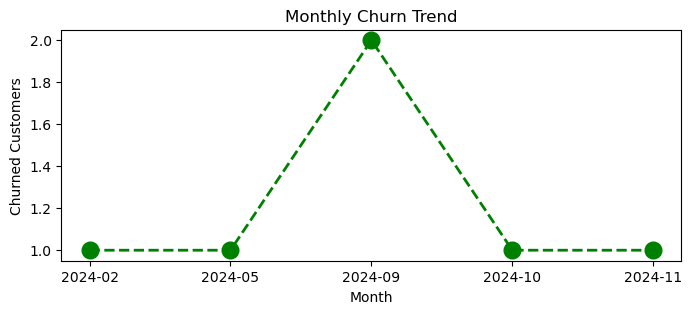

In [60]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] ==1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=12)
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show

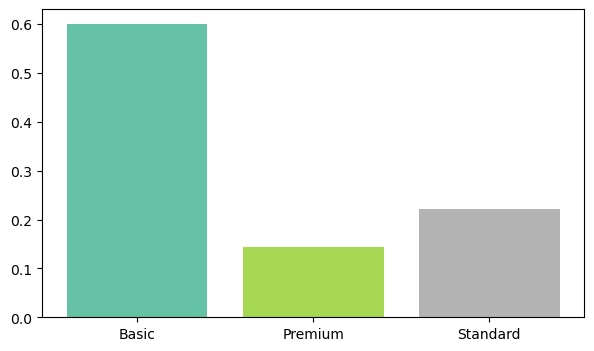

In [61]:
# 4.2 Churn By Plan Type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(7,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

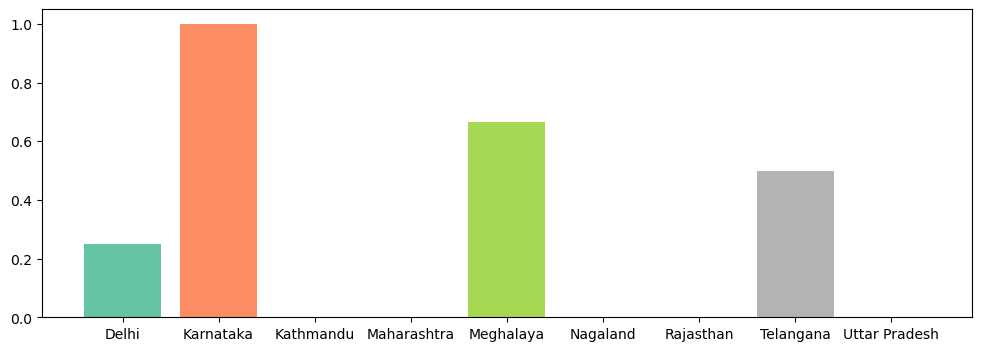

In [62]:
# 4.3 Churn by State
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

In [63]:
# Visualization using Seaborn

In [64]:
# encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'cutomer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [65]:
df_visual[['plan_type', 'contract_type','churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [67]:
# incorrect method of encoding - as numbers are not assigned based on priority
df_encoded = df_visual[['plan_type', 'contract_type','churn_score', 'churn_flag', 'churn_risk', 'escalations']]

categorial_cols = ['plan_type', 'contract_type','churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

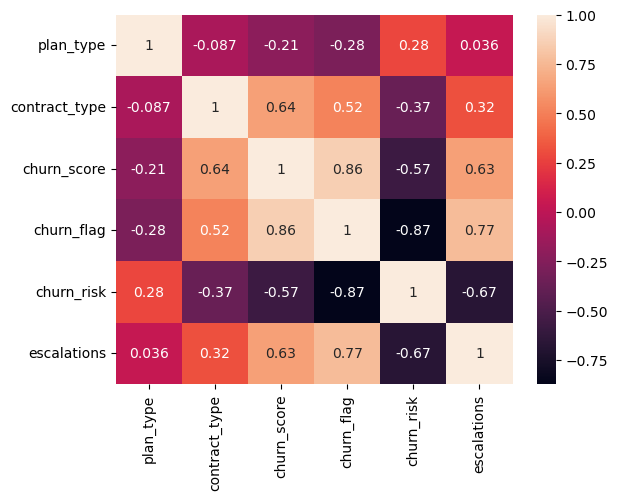

In [68]:
# Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

In [69]:
df_visual['churn_risk'].unique()

array(['low', 'high', 'med'], dtype=object)

In [70]:
# correct method of encoding - as numbers are not assigned based on priority
df_encoded = df_visual[['plan_type', 'contract_type','churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
     'plan_type' : ['Basic','Premium', 'Standard'],
     'contract_type' : ['Monthly', 'Annual'],
     'churn_risk' : ['low', 'med', 'high']
      }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [71]:
df_visual[['plan_type', 'contract_type','churn_score', 'churn_flag', 'churn_risk', 'escalations']].head

<bound method NDFrame.head of    plan_type contract_type  churn_score  churn_flag churn_risk  escalations
0   Standard        Annual           12           0        low            0
1    Premium        Annual           91           1       high            1
2      Basic       Monthly           34           0        low            0
3    Premium        Annual            8           0        low            0
4   Standard       Monthly           88           1       high            1
5   Standard        Annual           22           0        low            0
6      Basic       Monthly           79           1       high            0
7    Premium        Annual            5           0        low            0
8   Standard       Monthly           34           0        low            0
9      Basic        Annual           41           0        low            0
10   Premium        Annual           14           0        low            0
11  Standard       Monthly           83           1       

<Axes: >

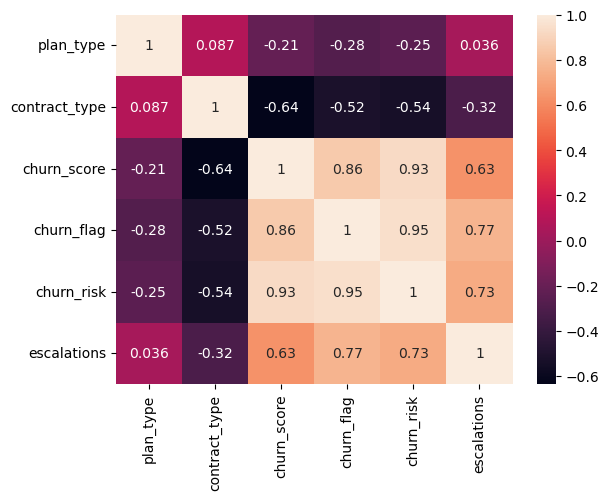

In [72]:
# Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot=True)

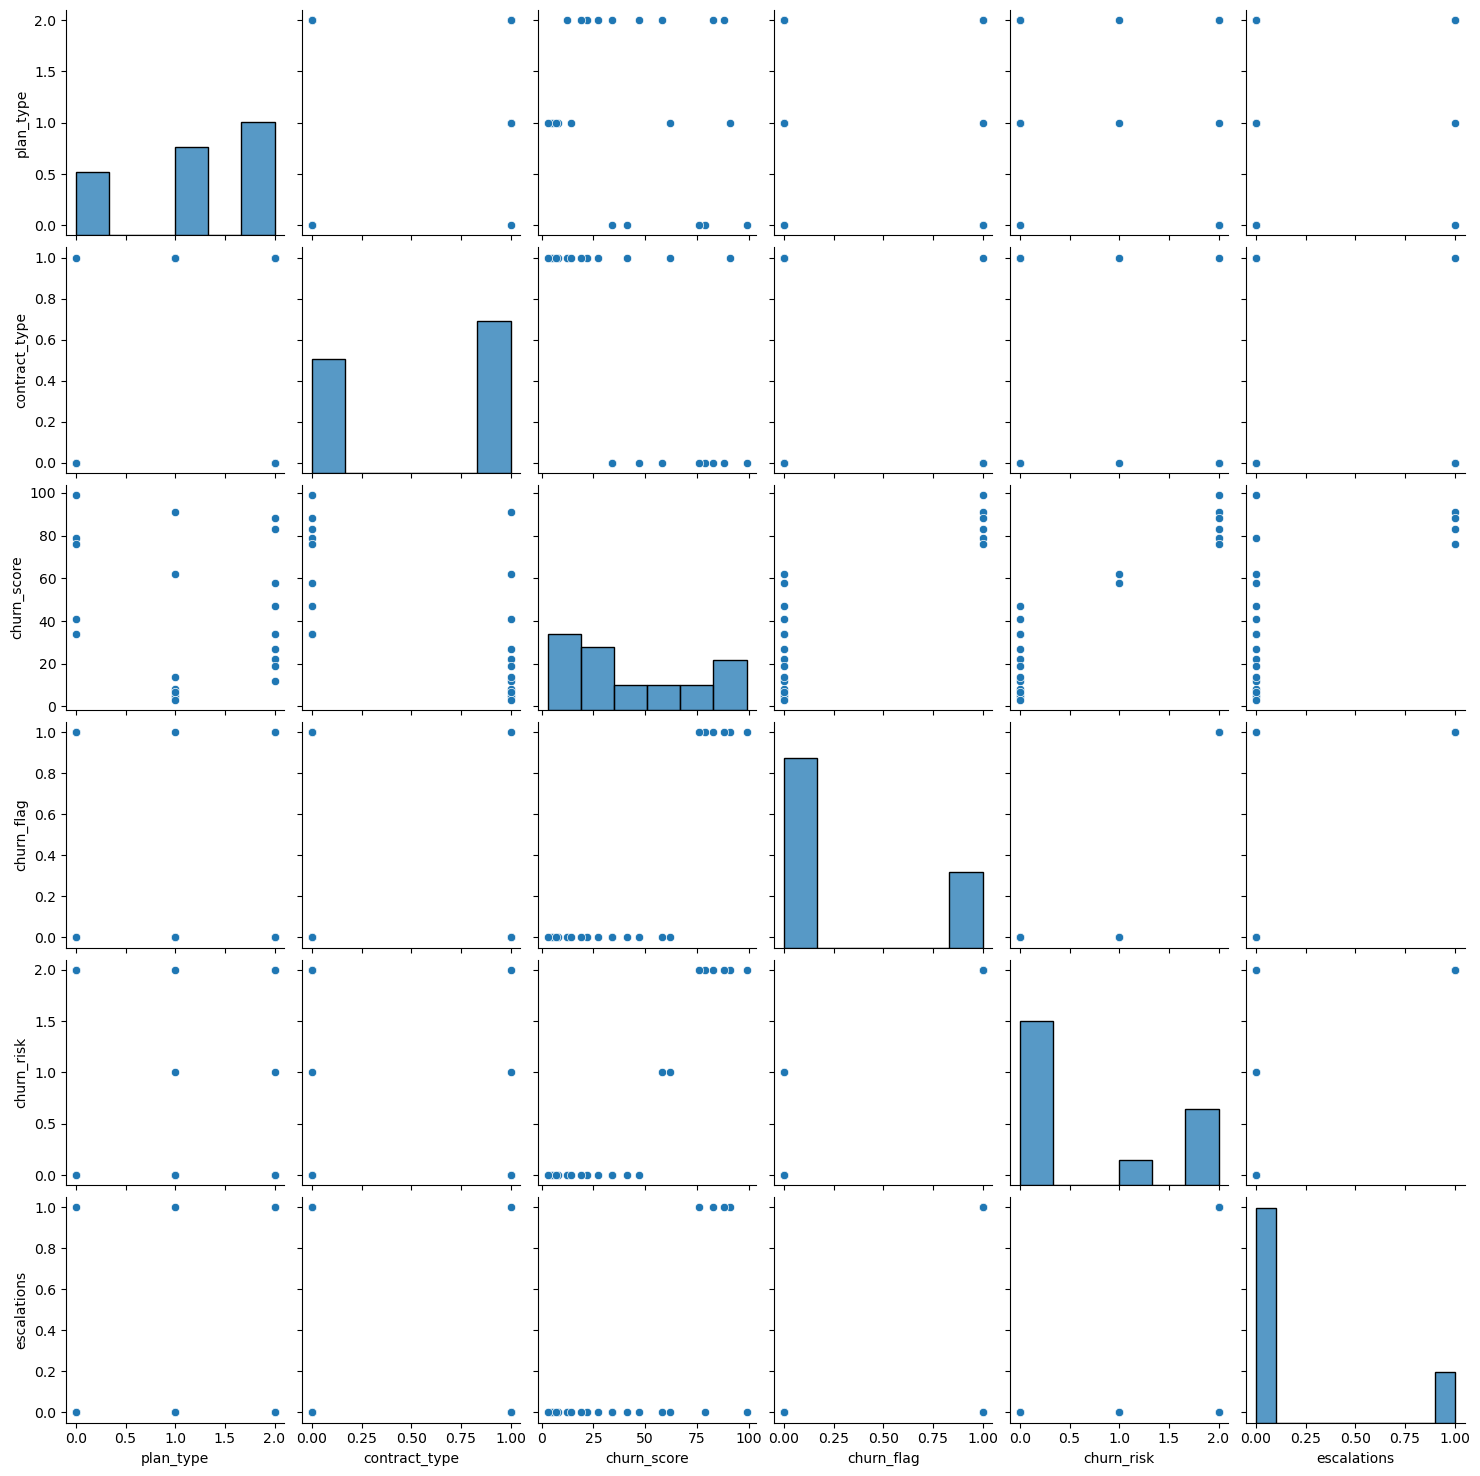

In [73]:
# pairplot - relashhip in a dataset
sns.pairplot(df_encoded)

In [74]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'cutomer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

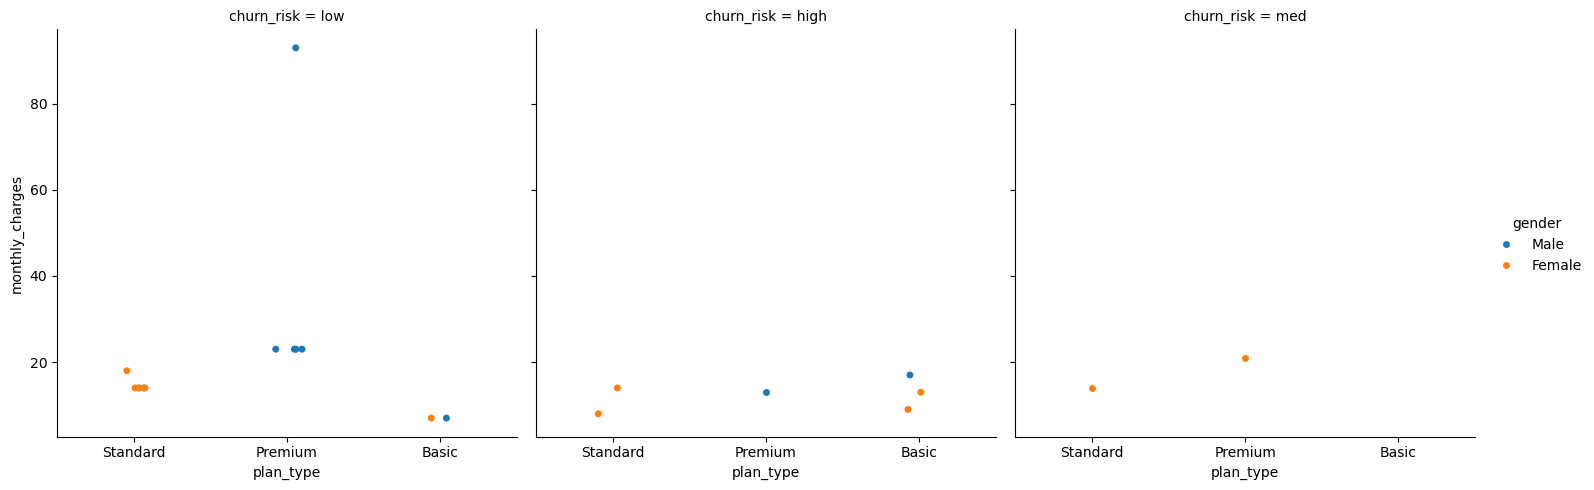

In [76]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(data=df_visual,
           x='plan_type',
           y='monthly_charges',
           hue='gender',
           col= 'churn_risk')

In [ ]:
# pivot Table

In [78]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [80]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'cutomer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='object')

In [82]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['customerid', 'monthly_charges', 'churn_flag'],
    aggfunc = {
    'customerid': 'nunique',
    'monthly_charges': 'sum',
    'churn_flag': 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [83]:
# Working with SQL in Python (pandas)

In [84]:
# create db in sql
conn = sqlite3.connect('test_database.sqlite')

# table details
conn.execute("CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)")

# commit and save 
conn.commit()

In [87]:
# insert data

cursor = conn.cursor()

# Write sql query to insert records in sql table
cursor.execute(
   """
          INSERT INTO users VALUES
          ('Tarun', 'India', '5000'),
          ('Ayush', 'Nepal', '2400'),
          ('Shikhar','Bangladesh', '2000')  
       """  
)

# commit and save 
conn.commit()

print("data inserted successfully")

data inserted successfully


In [88]:
# check inserted data in table
conn = sqlite3.connect('test_database.sqlite')
query = """SELECT * FROM users"""

df_results = pd.read_sql(query, conn)

df_results.head()

,first_name,country,budget
0,Tarun,India,5000
1,Ayush,Nepal,2400
2,Shikhar,Bangladesh,2000


In [89]:
# aggregation
query = """
           SELECT country, sum(budget) as total_budget
           FROM users
           GROUP BY country
"""  
df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,Bangladesh,2000
1,India,5000
2,Nepal,2400


In [90]:
# always close the conn with db once the task is over
conn.close()